In [1]:
# !pip install openfermion
import itertools

import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from openfermion import normal_ordered
from openfermion.ops import BosonOperator
from sympy import I, Symbol, solve
from tqdm.notebook import tqdm

This notebooks contains 2 parts:
1) is some calculations over term coefficients used to see order of magnitudes for each kind of term relative to the rate of some intended qubit exchange drive.
2) using openfermion to perform the polynomial expansion and normal ordering of terms. The tuple representation I used (coefficient operator, complex phase exponential term) made it useful for assigning frequencies and grouping terms. I used this for verifying I was including all the proper drivable terms with correct coefficients (as sometimes the binomial expansion stuff with normal ordering is hard to make sure you aren't counting slightly wrong)

In [ ]:
# Device parameters
n_s = 4
lambdaq = 0.1
eta = np.sqrt(n_s)
alpha = 120e6  # 120 MHz
N_q = 4
g3 = 60e6  # Coupling strength g3 = 60 MHz

# Intra-module prefactors
intra_prefactors = [
    6 * eta * lambdaq**2 * g3,  # qubit-qubit conversion
    6 * eta * lambdaq * g3,  # snail-qubit conversion
    alpha * eta**2 * lambdaq**3,  # snail-qubit sub conv
    3 * eta**2 * lambdaq * g3,  # qubit sub harmonic (1/2)
    alpha * eta**3 * lambdaq**3 / 3,  # qubit sub harmonic (1/3)
    3 * eta**2 * g3,  # snail sub harmonic (1/2)
    N_q * alpha * eta**3 * lambdaq**4 / 3,  # snail sub harmonic (1/3)
]

# Inter-module prefactors (with adjusted lambda powers)
inter_prefactors = [
    6 * eta * lambdaq**4 * g3,  # qubit-qubit conversion (overlapping qubit)
    6 * eta * lambdaq**6 * g3,  # qubit-qubit conversion (non-overlapping qubit)
    6 * eta * lambdaq**3 * g3,  # snail-qubit conversion (overlapping qubit)
    6 * eta * lambdaq**5 * g3,  # snail-qubit conversion (non-overlapping qubit)
    3 * eta**2 * lambdaq**3 * g3,  # qubit sub harmonic (non-overlapping)
    3 * eta**2 * g3 * lambdaq**2,  # snail sub harmonic (neighbor module)
]

# Normalize prefactors by the first term (qubit-qubit conversion) of intra-module
intra_normalized = [p / intra_prefactors[0] for p in intra_prefactors]
inter_normalized = [p / intra_prefactors[0] for p in inter_prefactors]

# Output results
print(intra_normalized)
print(inter_normalized)

[1.0, 10.0, 0.06666666666666667, 10.0, 0.04444444444444444, 99.99999999999997, 0.017777777777777774]
[0.009999999999999997, 0.0001, 0.1, 0.001, 0.1, 1.0]


In [ ]:
1 / (intra_prefactors[0] * (2 / np.pi)) * 1e9

218.16615649929113

In [ ]:
#  -\alpha_i*\eta**3*\lambda**3 - \alpha_i*\eta*\lambda**3 - \alpha_i*\eta*\lambda
[alpha * eta**3 * lambdaq**3, alpha * eta * lambdaq**3, alpha * eta * lambdaq]
sum(
    [alpha * eta**3 * lambdaq**3, alpha * eta * lambdaq**3, alpha * eta * lambdaq]
) / intra_prefactors[0]

3.499999999999999

In [ ]:
# 4*\alpha_i*\eta**3*\lambda**4 + 4*\alpha_i*\eta*\lambda**4 + 4*\alpha_i*\eta*\lambda**2 ([0^] + [0])
temp = (
    4 * alpha * eta**3 * lambdaq**4
    + 4 * alpha * eta * lambdaq**4
    + 4 * alpha * eta * lambdaq**2
)
temp / intra_prefactors[0]

1.4

In [ ]:
# Define symbols for parameters
ws = Symbol("w_s", real=True, positive=True)  # Frequency for s operator
wp = Symbol("w_p", real=True, positive=True)  # Pump frequency
eta = Symbol("\\eta", real=True)  # Scalar for eta, assume real for simplifications
eta_star = eta.conjugate()  # Complex conjugate of eta
lambda_si = Symbol("\\lambda", real=True, positive=True) # g_sqi / delta
g3 = Symbol("g_3", real=True, positive=True)
alpha_i = Symbol("\\alpha_i", real=True, positive=True)
N = 4  # Number of qubit modes
t = Symbol("t", real=True, positive=True)

# Define the cubic term components as (BosonOperator, frequency term)
cubic_terms = (
    [
        (BosonOperator("0", 1), -ws),  # s operator with -ws frequency
        (BosonOperator("0^", 1), ws),  # s^ operator with ws frequency
        (BosonOperator("", eta), -wp),  # eta with -wp frequency
        (BosonOperator("", eta_star), wp),  # eta* with wp frequency
    ]
    + [(BosonOperator(f"{i}", lambda_si), -Symbol(f"w_q{i}")) for i in range(1, N + 1)]
    + [(BosonOperator(f"{i}^", lambda_si), Symbol(f"w_q{i}")) for i in range(1, N + 1)]
)

# Define the quartic term components for each qubit mode `q_i`
quartic_terms = []
for i in range(1, N + 1):
    # Define the terms for (q_i^ + q_i - lambda_si * (s, s^, eta, eta^ )) for each i
    quartic_base_terms = [
        (BosonOperator(f"{i}", 1), -Symbol(f"w_q{i}")),  # q_i with -w_qi frequency
        (BosonOperator(f"{i}^", 1), Symbol(f"w_q{i}")),  # q_i^ with w_qi frequency
        (BosonOperator("0", -lambda_si), -ws),
        (BosonOperator("0^", -lambda_si), ws),
        (BosonOperator("", -lambda_si * eta), -wp),
        (BosonOperator("", -lambda_si * eta_star), wp),
    ]
    quartic_terms.append(quartic_base_terms)


# Function to generate polynomial expansions for a list of terms with a specific order
def generate_polynomial_terms(terms, order):
    polynomial_terms = list(itertools.product(terms, repeat=order))
    expanded_terms = []

    for combo in polynomial_terms:
        # Separate the BosonOperator and frequency terms
        operator_product = BosonOperator("", 1)  # Start with the identity operator
        frequency_sum = 0  # Initialize frequency sum

        for op, freq in combo:
            operator_product *= op
            frequency_sum += freq

        expanded_terms.append((operator_product, frequency_sum))

    return expanded_terms


# Expand the cubic term (g3 * (cubic_terms)^3)
expanded_cubic_terms = [
    (g3 * term[0], term[1]) for term in generate_polynomial_terms(cubic_terms, 3)
]

# Expand the quartic term for each `q_i` (alpha_i/12 * (quartic_base_terms)^4)
expanded_quartic_terms = []
for quartic_base_terms in quartic_terms:
    expanded_terms = generate_polynomial_terms(quartic_base_terms, 4)
    expanded_quartic_terms.extend(
        [(alpha_i / 12 * term[0], term[1]) for term in expanded_terms]
    )

expanded_quintic_terms = []
for quartic_base_terms in quartic_terms:
    expanded_terms = generate_polynomial_terms(quartic_base_terms, 5)
    expanded_quartic_terms.extend(
        [(alpha_i / 12 * term[0], term[1]) for term in expanded_terms]
    )

In [3]:
# Display a few terms to verify structure
print("Cubic Terms (Expanded):")
for term in expanded_cubic_terms[:3]:  # Show first few terms as example
    print(term)

print("\nQuartic Terms (Expanded):")
for term in expanded_quartic_terms[:3]:  # Show first few terms as example
    print(term)

Cubic Terms (Expanded):
(g_3 [0 0 0], -3*w_s)
(g_3 [0 0 0^], -w_s)
(\eta*g_3 [0 0], -w_p - 2*w_s)

Quartic Terms (Expanded):
(\alpha_i/12 [1 1 1 1], -4*w_q1)
(\alpha_i/12 [1 1 1 1^], -2*w_q1)
(-\alpha_i*\lambda/12 [0 1 1 1], -3*w_q1 - w_s)


In [4]:
# for all terms, group by exp term
expanded_terms = expanded_cubic_terms + expanded_quartic_terms
expanded_terms_grouped = {}
for term in expanded_terms:
    if term[1] not in expanded_terms_grouped:
        expanded_terms_grouped[term[1]] = []
    expanded_terms_grouped[term[1]].append(term[0])

# we wait to combine them together because calls to sum and normal_ordered are expensive
# when it uses custom implementation specific to BosonOperator
simplified_terms_dict = {}
for k, v in tqdm(list(expanded_terms_grouped.items())[:]):
    # simplified_terms_dict[k] = normal_ordered(v[0].accumulate(v[1:]))
    simplified_terms_dict[k] = normal_ordered(sum(v))  # NOTE: slower?

  0%|          | 0/569 [00:00<?, ?it/s]

In [5]:
# look at some example terms
# list(simplified_terms_dict.items())[40:50]
simplified_terms_dict

{-3*w_s: g_3 [0 0 0],
 -w_s: 6*\eta**2*g_3 + 12*\lambda**2*g_3 + 3*g_3 [0] +
 6*\lambda**2*g_3 [0 1^ 1] +
 6*\lambda**2*g_3 [0 2^ 2] +
 6*\lambda**2*g_3 [0 3^ 3] +
 6*\lambda**2*g_3 [0 4^ 4] +
 3*g_3 [0^ 0 0],
 -w_p - 2*w_s: 3*\eta*g_3 [0 0],
 w_p - 2*w_s: 3*\eta*g_3 [0 0],
 -w_q1 - 2*w_s: 3*\lambda*g_3 [0 0 1],
 -w_q2 - 2*w_s: 3*\lambda*g_3 [0 0 2],
 -w_q3 - 2*w_s: 3*\lambda*g_3 [0 0 3],
 -w_q4 - 2*w_s: 3*\lambda*g_3 [0 0 4],
 w_q1 - 2*w_s: 3*\lambda*g_3 [0 0 1^],
 w_q2 - 2*w_s: 3*\lambda*g_3 [0 0 2^],
 w_q3 - 2*w_s: 3*\lambda*g_3 [0 0 3^],
 w_q4 - 2*w_s: 3*\lambda*g_3 [0 0 4^],
 w_s: 6*\eta**2*g_3 + 12*\lambda**2*g_3 + 3*g_3 [0^] +
 3*g_3 [0^ 0^ 0] +
 6*\lambda**2*g_3 [0^ 1^ 1] +
 6*\lambda**2*g_3 [0^ 2^ 2] +
 6*\lambda**2*g_3 [0^ 3^ 3] +
 6*\lambda**2*g_3 [0^ 4^ 4],
 -w_p: 3*\eta**3*g_3 + 12*\eta*\lambda**2*g_3 + 3*\eta*g_3 [] +
 6*\eta*g_3 [0^ 0] +
 6*\eta*\lambda**2*g_3 [1^ 1] +
 6*\eta*\lambda**2*g_3 [2^ 2] +
 6*\eta*\lambda**2*g_3 [3^ 3] +
 6*\eta*\lambda**2*g_3 [4^ 4],
 w_p: 3*


### SNAIL Subharmonics
For SNAIL subharmonics, we have:

<!-- 
\[
-2 w_p + w_s : 3 \eta^2 g_3 [0^\dagger]
\]

\[
2 w_p - w_s : 3 g_3 \bar{\eta}^2 [0]
\]

\[
-3 w_p + w_s : \alpha_i \eta^3 \lambda^4 [0^\dagger]
\]

\[
3 w_p - w_s : \alpha_i \lambda^4 \bar{\eta}^3 [0]
\]
-->

- When  $ w_p := \frac{w_s}{2}  $, it activates  $ 3 g_3 \left(\eta^2 s^\dagger + \bar{\eta}^2 s\right)  $,
- When  $ w_p := \frac{w_s}{3}  $, it activates  $ (N/3) * \alpha_i \lambda^4 \left(\eta^3 s^\dagger + \bar{\eta}^3 s\right)  $.

Here,  $ s  $ represents the SNAIL operator, $N$ is number of qubits.

### Qubit Subharmonics
For qubit subharmonics, we have:

<!-- 
\[
2 w_p - w_{q1} : 3 g_3 \lambda_{si} \bar{\eta}^2 [1]
\]

\[
-2 w_p + w_{q1} : 3 \eta^2 g_3 \lambda_{si} [1^\dagger]
\]

\[
3 w_p - w_{q1} : -\frac{1}{3} \alpha_i \lambda_{si}^3 \bar{\eta}^3 [1]
\]

\[
-3 w_p + w_{q1} : -\frac{1}{3} \alpha_i \eta^3 \lambda_{si}^3 [1^\dagger]
\]
-->

- When  $ w_p := \frac{w_q}{2}  $, it activates  $ 3 g_3 \lambda_{si} \left(\bar{\eta}^2 q + \eta^2 q^\dagger \right)  $,
- When  $ w_p := \frac{w_q}{3}  $, it activates  $ -\frac{1}{3} \alpha_i \lambda_{si}^3 \left(\bar{\eta}^3 q + \eta^3 q^\dagger \right)  $.

single qubit gates
<!-- 
 -w_p + w_q1: -2*\alpha_i*\eta*\lambda**3 [0^ 0 1^] +
 -\alpha_i*\eta**3*\lambda**3 - \alpha_i*\eta*\lambda**3 - \alpha_i*\eta*\lambda [1^] +
 -\alpha_i*\eta*\lambda [1^ 1^ 1],

 w_p - w_q1: -2*\alpha_i*\eta*\lambda**3 [0^ 0 1] +
 -\alpha_i*\eta**3*\lambda**3 - \alpha_i*\eta*\lambda**3 - \alpha_i*\eta*\lambda [1] +
 -\alpha_i*\eta*\lambda [1^ 1 1] -->

 <!-- -\alpha_i*\eta**3*\lambda**3 - \alpha_i*\eta*\lambda**3 - \alpha_i*\eta*\lambda [1^] +
 -\alpha_i*\eta**3*\lambda**3 - \alpha_i*\eta*\lambda**3 - \alpha_i*\eta*\lambda [1] + -->

 -\alpha_i*\eta**3*\lambda**3 - \alpha_i*\eta*\lambda**3 - \alpha_i*\eta*\lambda ([1^] +[1])]


snail 1q gate

 <!-- -w_p + w_s: 4*\alpha_i*\eta**3*\lambda**4 + 4*\alpha_i*\eta*\lambda**4 + 4*\alpha_i*\eta*\lambda**2 [0^] +
 4*\alpha_i*\eta*\lambda**4 [0^ 0^ 0] +
 2*\alpha_i*\eta*\lambda**2 [0^ 1^ 1] +
 2*\alpha_i*\eta*\lambda**2 [0^ 2^ 2] +
 2*\alpha_i*\eta*\lambda**2 [0^ 3^ 3] +
 2*\alpha_i*\eta*\lambda**2 [0^ 4^ 4],

w_p - w_s: 4*\alpha_i*\eta**3*\lambda**4 + 4*\alpha_i*\eta*\lambda**4 + 4*\alpha_i*\eta*\lambda**2 [0] +
 2*\alpha_i*\eta*\lambda**2 [0 1^ 1] +
 2*\alpha_i*\eta*\lambda**2 [0 2^ 2] +
 2*\alpha_i*\eta*\lambda**2 [0 3^ 3] +
 2*\alpha_i*\eta*\lambda**2 [0 4^ 4] +
 4*\alpha_i*\eta*\lambda**4 [0^ 0 0], -->


<!-- 4*\alpha_i*\eta**3*\lambda**4 + 4*\alpha_i*\eta*\lambda**4 + 4*\alpha_i*\eta*\lambda**2 ([0^] + [0]) + -->

In [11]:
# we want to split the terms into two groups
# (a) dependent on w_p vs (b) independent of w_p
# (a) are activated by the pump whereas (b) are thus always present
# additionally, for a term in (a), we solve for pump frequency such that the term is zero
# and then make that value the new dictionary key

qubit_frequency_values = [4, 17 / 3, 6, 5.5]
snail_frequency = 13 / 3
symbol_subs = {
    Symbol(f"w_q{i}"): freq for i, freq in enumerate(qubit_frequency_values, 1)
}
symbol_subs.update({ws: snail_frequency})
sub_terms_dict = {}
for k, v in simplified_terms_dict.items():
    new_k = k.subs(symbol_subs)
    if new_k not in sub_terms_dict:
        sub_terms_dict[new_k] = 0
    sub_terms_dict[new_k] += v

sub_terms_dict_wp = {}
sub_terms_dict_reverse = {}
sub_terms_dict_always = {}
for k, v in tqdm(sub_terms_dict.items()):
    if wp in k.free_symbols:
        wp_val = solve(k, wp)
        if not wp_val:
            continue
        if not wp_val[0] in sub_terms_dict_wp:
            sub_terms_dict_wp[wp_val[0]] = 0
        sub_terms_dict_wp[wp_val[0]] += v
        sub_terms_dict_reverse[str(v)] = wp_val[0]

    else:
        sub_terms_dict_always[k] = v

  0%|          | 0/507 [00:00<?, ?it/s]

In [8]:
# # prune any where the 0<=key<=0.5
# print(len(sub_terms_dict_always))
# # interesting to look at if there are any terms present that could be persistent error term
# ie plt.xlabel(r"$\theta$ (Frequency, $H = \text{operator} \cdot e^{-i t \theta}$)")
# sub_terms_dict_always = {k: v for k, v in sub_terms_dict_always.items() if 0 <= k < 0.5}
# print(len(sub_terms_dict_always))

print(len(sub_terms_dict_wp))
# prune such that keep only if between 0 and 2
filtered_sub_terms_dict_wp = {
    k: v for k, v in sub_terms_dict_wp.items() if 0 <= k <= 2.2
}
print(len(filtered_sub_terms_dict_wp))
# sub_terms_dict_wp
# sub_terms_dict_reverse

63
16


In [ ]:
op = list(filtered_sub_terms_dict_wp.items())[-2][1]
simplfied_op_string = []


def _format_operator_tuple(op_tuple):
    # op_tuple is a tuple (int, int)
    # first element
    # Replace "0" with "s" and "i" with "q_i" format for qubits
    # second element, if 1 gets a ^\dagger
    op_str = ""
    if op_tuple[0] == 0:
        op_str += "s"
    else:
        op_str += f"q_{op_tuple[0]}"
    if op_tuple[1] == 1:
        op_str += "^{\\dagger}"
    return op_str


from sympy import factor, latex


def _format_operator(op):
    ops = 0
    for termk, termv in op.terms.items():
        ops += termv * Symbol(
            " ".join(_format_operator_tuple(op_tuple) for op_tuple in termk)
        )
    return f"${latex(factor(ops), fold_short_frac=True)}$"


formated_sub_terms_dict_wp = {
    k: _format_operator(v) for k, v in filtered_sub_terms_dict_wp.items()
}
formated_sub_terms_dict_wp

{1.33333333333333: '$6 \\eta \\lambda g_{3} \\left(s q_2^{\\dagger} + s^{\\dagger} q_2\\right)$',
 1.66666666666667: '$6 \\eta \\lambda g_{3} \\left(\\lambda q_1 q_2^{\\dagger} + \\lambda q_1^{\\dagger} q_2 + s q_3^{\\dagger} + s^{\\dagger} q_3\\right)$',
 1.16666666666667: '$6 \\eta \\lambda g_{3} \\left(s q_4^{\\dagger} + s^{\\dagger} q_4\\right)$',
 2.16666666666667: '$3 \\eta^{2} g_{3} \\left(s + s^{\\dagger}\\right)$',
 0.333333333333333: '$6 \\eta \\lambda g_{3} \\left(\\lambda q_2 q_3^{\\dagger} + \\lambda q_2^{\\dagger} q_3 + s q_1^{\\dagger} + s^{\\dagger} q_1\\right)$',
 2: '$- \\eta \\lambda \\left(\\alpha_{i} \\eta^{2} \\lambda^{2} q_{3} + \\alpha_{i} \\eta^{2} \\lambda^{2} q_3^{\\dagger} - 9 \\eta g_{3} q_{1} - 9 \\eta g_{3} q_1^{\\dagger} - 18 \\lambda g_{3} q_1 q_3^{\\dagger} - 18 \\lambda g_{3} q_1^{\\dagger} q_3\\right) / 3$',
 1.50000000000000: '$6 \\eta \\lambda^{2} g_{3} \\left(q_1 q_4^{\\dagger} + q_1^{\\dagger} q_4\\right)$',
 0.166666666666667: '$- \\eta \\lambda

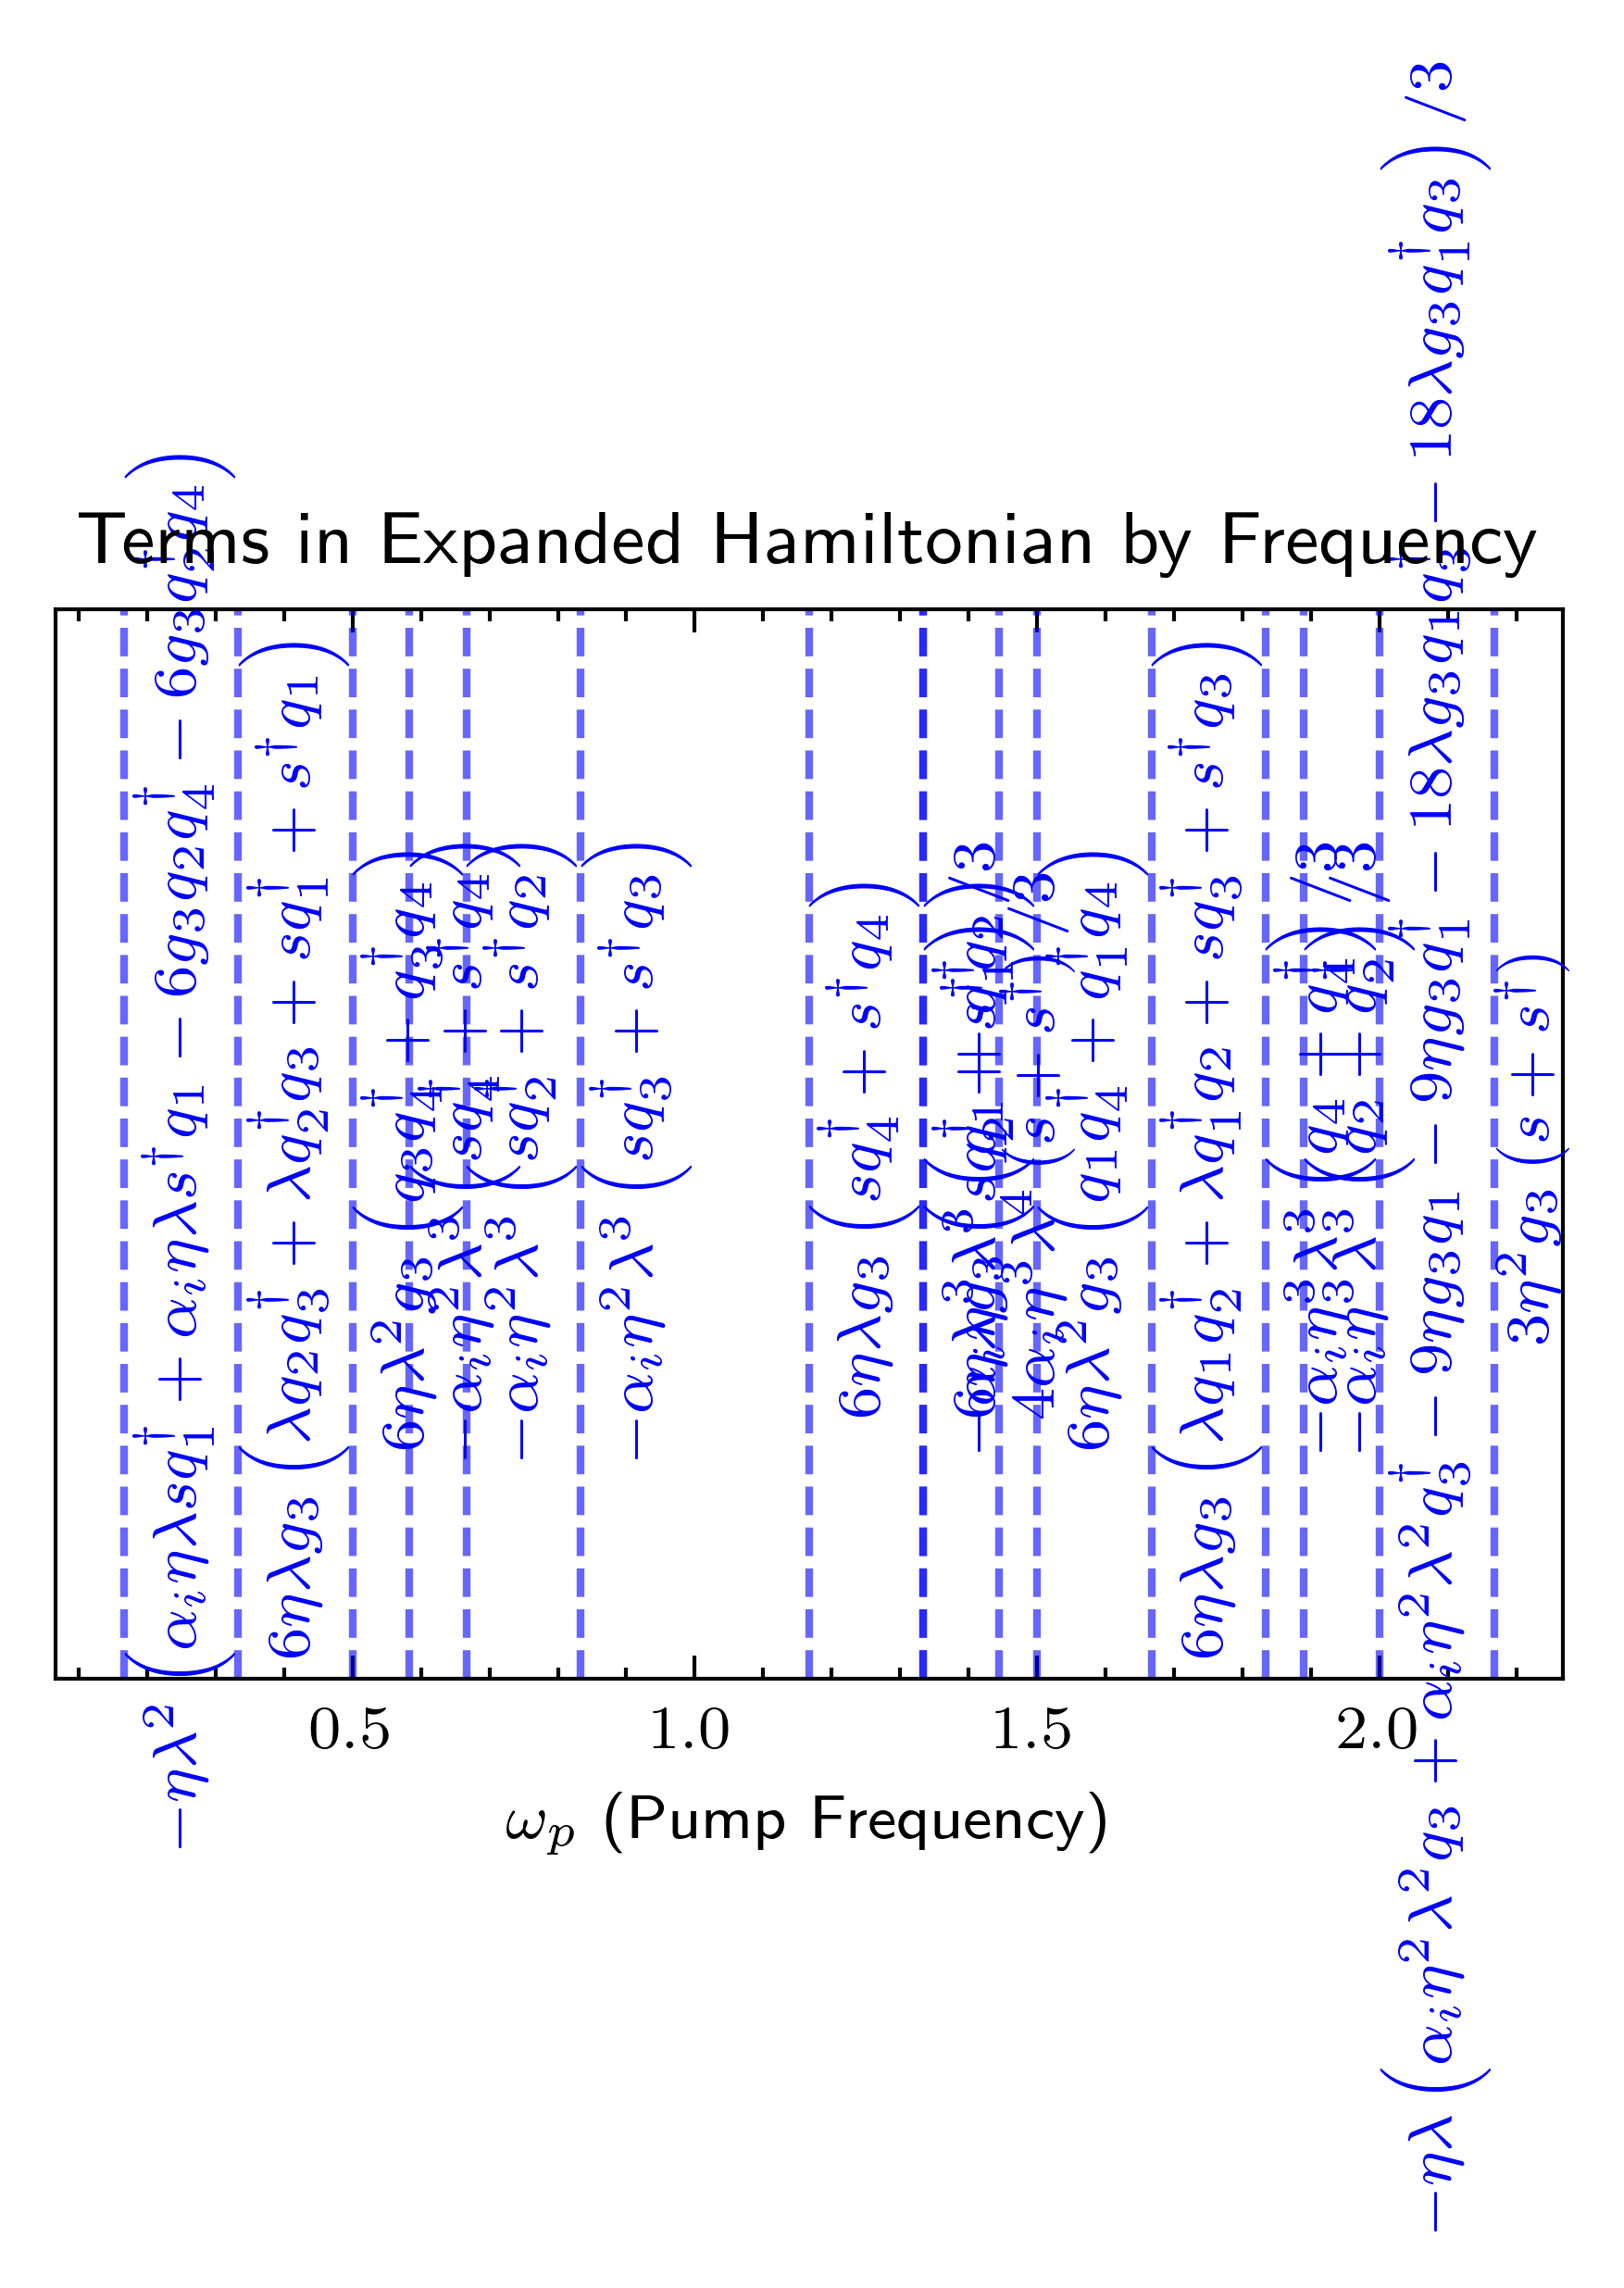

In [10]:
# Plot the results using consistent style
# need a helper to replace BosonOperator with strings
# {0: "s", i: "q_i"},; remove [], replace ^ with ^\dagger
# def _format_operator_string(operator_string):
#     operator_string = str(operator_string).replace("\n", "")

#     # Replace "0" with "s" and "i" with "q_i" format for qubits
#     operator_string = re.sub(r"\b0\b", "s", operator_string)
#     operator_string = re.sub(r"\b(\d+)\b", r"q_\1", operator_string)
#     # Replace "^" with "^\dagger"
#     operator_string = operator_string.replace("^", "^\dagger")
#     # Replace "[" and "]" with "(" and ")"
#     operator_string = operator_string.replace("[", "(").replace("]", ")")
#     # Replace "*" with a space
#     operator_string = operator_string.replace("*", " ")
#     # Convert conjugate(anything) to anything^*
#     operator_string = re.sub(r"conjugate\((.+?)\)", r"\1^*", operator_string)
#     return "$" + operator_string + "$"


with plt.style.context(["ieee", "use_mathtext", "science"]):
    fig, ax1 = plt.subplots(figsize=(3.5, 2.5))  # Adjust figure size

    # Plot each frequency term as a vertical line with label
    for frequency, operator_string in formated_sub_terms_dict_wp.items():
        ax1.axvline(x=frequency, color="blue", linestyle="--", alpha=0.6)
        ax1.text(
            frequency,
            0.5,
            operator_string,
            rotation=90,
            verticalalignment="center",
            color="blue",
            fontsize=8,
        )

    # Formatting the plot
    ax1.set_xlabel(r"$\omega_p$ (Pump Frequency)")
    ax1.set_title("Terms in Expanded Hamiltonian by Frequency")
    ax1.set_yticks([])  # Remove y-axis ticks for a cleaner 1D appearance
plt.show()